# Conditionnal VAE

Project : 
* explain what a conditional VAE is (algorithm type, diff with traditional VAE, loss fonctions used, ...)
* train it on Fashion MNIST dataset (using pytorch)
* for each class, generate 5 new samples
* explain choices made : architecture, layer types, activations, hyper-parameters (batch size, learning rate, number of epochs, regularization weight) and the choice of the loss function
* include links of paper/articles/ressources...
* include code that helped decide on the above choices
* plot visualizations of the results (latent space (TSNE), curves of the terms of loss function during training)

Ressources used : 
* https://towardsdatascience.com/conditional-variational-autoencoders-for-text-to-image-generation-1996da9cefcb/ (convolutionnal cvae architecture)
* https://www.ibm.com/fr-fr/think/topics/variational-autoencoder (general infos on cvae)
* https://medium.com/@abz200026/image-generation-via-conditional-variational-autoencoders-cvae-aab0c7790a87 (cvae on mnist fashion)
* https://www.kaggle.com/code/badreddineb/mnistfashion-vae (cvae on fashion mnist)



## What is a conditional VAE ?

 A conditional vae (cvae) differs from a traditional vae by learning on a training set with a reference variability. For instance, on the MNIST Fashion dataset, the reference variability is the type of clothes (t-shirt, trousers, shirts, etc.). It's a self supervised algorithm : the CVAE learn on the inputs. It rely on an encoder projecting inputs on a latent space (with a much smaller dimension than the input dimension). Then, it reconstruct the input through the decoder. The loss function used is the difference between the output and the input (ie how accurate is the autoencoder to reconstruct the input). The model performance rely on the bottleneck : if the latent space dimension is too large, the model might overfit the data. CVAE algorithms rely as well on a KL regularization (developped in the Loss function part.)

### Architecture
As said previously, the architecture of a cvae only differs from a traditional vae by adding another input for both the encoder and the decoder (reference variability, eg a class). That said, the architecture is the following : an encoder taking as input a certain type of data (in this example, the images of clothes) and the reference variability (here, the class the image belongs to). The encoder then encode the input into a latent space of much smaller dimension (in vae and cvae, it learn a latent space distribution and sample latent variable from this learnt distribution). Then, the decoder (taking as input the corresponding latent variable and reference variability) reconstructs a corresponding output, as close as possible to the input.

#### Encoder and decoder architecture

The encoder is typically built using full connected layers or convolution layers. In this example, since we are working with images, we will use convolution layers (state of the art for vae architecture for image generation because convolutionnal architectures preserves the spatial localization of the images). The last layer of the encoder is a dense layer (for the mean and for the log of the variance). The used activations are Relu between the layers and the identity activation for the last layer. The decoder is usually the symetric of the encoder.

### Usage
An useful application could be to use conditional vaes as generative algorithm. Indeed, for a given class i, the cvae learn the distribution of a latent space (with a much smaller dimension than the input one). Then, for a sampled latent variable (sampled using the distribution learnt for the class i), the user can generate an output belonging to the class i. 


### Loss function
The used training function is the same that the one used with VAEs : a two term training function, one term being the reconstruction error (MSE or BCE if normalized / binary input). The other term is a regularization term : it's a KL divergence term constraining the learnt distribution to match a given distribution (state of the art : N(0,1)). The loss function is written as follow : 
$$
\mathcal{L}_{CVAE}(\theta, \phi; x, y) = - \mathbb{E}_{q_{\phi}(z|x, y)} \left[ \log p_{\theta}(x|z, y) \right] + \beta D_{KL} \left( q_{\phi}(z|x, y) \parallel p(z|y) \right)
$$
Here, x is the input (MNIST Fashion : an image), y the reference variability (class, ex : t-shirt), z a latent variable, $q_{\phi}(z|x,y)$ learnt distribution for the encoder, $p_{\theta}(x|z,y)$ the decoder, $p_{theta}(z|y)$ a prior distribution on the latent space (given, typically N(0,1)). $\phi, \theta$ are the encoder and decoder parameters.

On this specific dataset, we will use cross entropy for the reconstruction loss. This is commonly use for greyscale image as we can say that the pixel value (between 0 and 1) is a "probability of pixel activation". MSE loss function for reconstruction would be effective as well, it's just a choice made with the help of existing litterature. Overall, community tends to use cross entropy for greyscale, simple images (such as images in mnist fashion) and to use MSE for multi channel complex images.

A choice can be made about using a regularization weight. Here, since BCE loss and KL divergence seem to be the same order of magnitude, we will not use a specific regularization weight (by default =1).

### Specific architecture choices.

According to litterature (a lot has been done with vae over MNIST dataset), with such sized images and such sized dataset (28*28, 70 000 images), a small and simple cnn (3 convolutionnal layers) as decoder is sufficient. We will test that over a more complex cnn (4 convolutionnal layer, max pooling). We will also test a CVAE built with MLP for encoder and decoder.

For activation functions, we used leaky relu for all of the layer except for the last layer of the decoder. For autoencoders and GANS, leaky relu is commonly used to avoid neuron deactivation (common thing with relu, if value of a neuron for several forward pass is x<0 => relu(x)=0 so null gradient and neuron deactivated). We used sigmoid on the last layer of the decoder because we want to predict a grey level for the picture (we can see it as a probability of activation for a pixel.)


### Training choices

For the more complex architecture, 50 epochs is enough (test loss converges). For the simple architecture, test loss converges aroung 30 epochs.
Hyperparameters such as learning rate, batch size etc were set according to already done projects on mnist fashion dataset(see documents used).

In [2]:
#imports
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "4"
import torch
from torch import nn
from torch.nn import functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [3]:

IMAGE_SIZE = 28 # images (28x28)
INPUT_CHANNELS = 1 
NUM_CLASSES = 10   
LATENT_DIM = 32  
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_losses = []
test_losses = []
train_bce_all, train_kld_all = [], []
test_bce_all, test_kld_all = [], []
transform = transforms.Compose([
    transforms.ToTensor(), 
    
    
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

As explained in the first part, choices of hyperparameters (Batch size, latent space dimension and learning rate) were set according to already existing VAE on the MNIST fashion dataset.

## Simple CVAE with 3 convolution layers.

Here, we build our first CVAE class : it's a simple CVAE with 3 conv layers for the encoder and 4 for the decoder. We also built a function to sample latent vectors via the reparametrization trick. We also design our losses (cross entropy + KL divergence).

In [ ]:
class ConditionalConvolutionalVAE(nn.Module):
    def __init__(self, input_channels, num_classes, latent_dim, img_size):
        super(ConditionalConvolutionalVAE, self).__init__()
        
        self.input_channels = input_channels
        self.num_classes = num_classes
        self.latent_dim = latent_dim
        self.img_size = img_size

   
        self.encoder_conv = nn.Sequential(
            
            nn.Conv2d(input_channels, 32, kernel_size=4, stride=2, padding=1), 
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2)
        )
        
        self.flattened_size = 128 * (img_size // 8) * (img_size // 8)

        
        self.fc_mu = nn.Linear(self.flattened_size + num_classes, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size + num_classes, latent_dim)

        
        self.decoder_input_fc = nn.Linear(latent_dim + num_classes, self.flattened_size)

        
        self.decoder_conv = nn.Sequential(
        
        nn.Conv2d(128, 64, kernel_size=3, padding=1),
        nn.LeakyReLU(0.2),
        nn.Upsample(scale_factor=2),
        
        nn.Conv2d(64, 32, kernel_size=3, padding=1),
        nn.LeakyReLU(0.2),
        nn.Upsample(scale_factor=2),
        
        nn.Conv2d(32, 16, kernel_size=3, padding=1),
        nn.LeakyReLU(0.2),
        
        nn.Upsample(size=(28, 28), mode='bilinear', align_corners=False), 
        
        nn.Conv2d(16, input_channels, kernel_size=3, padding=1),
        nn.Sigmoid()
    )
        
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, labels=None, **kwargs):

        if labels is None:
            labels = kwargs.get('labels')
      
        
        h_conv = self.encoder_conv(x)

        
        h_flat = h_conv.view(-1, self.flattened_size)

        
        h_concat = torch.cat([h_flat, labels], dim=1)
        
        mu = self.fc_mu(h_concat)
        logvar = self.fc_logvar(h_concat)
        
        
        z = self.reparameterize(mu, logvar)
        
        
        z_concat = torch.cat([z, labels], dim=1)

        
        h_dec_fc = self.decoder_input_fc(z_concat)
        
        
        h_dec_reshaped = h_dec_fc.view(-1, 128, self.img_size // 8, self.img_size // 8)
        
        
        recon_x = self.decoder_conv(h_dec_reshaped)
        
        return recon_x, mu, logvar

    
    def generate(self, z, y):
        
        z_concat = torch.cat([z, y], dim=1)
        h_dec_fc = self.decoder_input_fc(z_concat)
        h_dec_reshaped = h_dec_fc.view(-1, 128, self.img_size // 8, self.img_size // 8)
        return self.decoder_conv(h_dec_reshaped)



def cvae_loss_function(recon_x, x, mu, logvar):
    # Reconstruction (BCE)
    BCE = F.binary_cross_entropy(recon_x.view(-1, IMAGE_SIZE*IMAGE_SIZE), 
                                 x.view(-1, IMAGE_SIZE*IMAGE_SIZE), 
                                 reduction='sum')
    # Régularisation (KLD)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KLD, BCE, KLD


## More complex architecture (VGG type)

Here, we design a second architecture, based on the VGG architecture. The decoder is the encoder symetric.

In [ ]:
class VGGConditionalVAE(nn.Module):
    def __init__(self, in_channels=1, num_classes=10, latent_dim=64, img_size=28):
        super(VGGConditionalVAE, self).__init__()
        
        self.img_size = img_size
        self.num_classes = num_classes
        self.latent_dim = latent_dim

        self.embed_class = nn.Linear(num_classes, img_size * img_size)
        self.embed_data = nn.Conv2d(in_channels, in_channels, kernel_size=1)

        
        c_in = in_channels + 1 
        
    
        self.enc_block1 = nn.Sequential(
            nn.Conv2d(c_in, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) 
        )
        

        self.enc_block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.flat_size = 128 * 7 * 7
        self.fc_mu = nn.Linear(self.flat_size, latent_dim)
        self.fc_var = nn.Linear(self.flat_size, latent_dim)

        
        self.decoder_input = nn.Linear(latent_dim + num_classes, self.flat_size)
        
        
        self.dec_block1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        
        self.dec_block2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, in_channels, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.enc_block1(x)
        x = self.enc_block2(x)
        x = x.view(-1, self.flat_size)
        return self.fc_mu(x), self.fc_var(x)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return eps * std + mu

    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(-1, 128, 7, 7)
        x = self.dec_block1(x)
        x = self.dec_block2(x)
        return x

    
    def forward(self, input, labels=None, **kwargs):
        
        if labels is None:
            labels = kwargs.get('labels')
        

        if labels is None:
             raise ValueError("Labels requis")

        
        if labels.dim() == 1:
            labels = F.one_hot(labels.long(), num_classes=self.num_classes).float()
        else:
            labels = labels.float()


        embedded_class = self.embed_class(labels)
        embedded_class = embedded_class.view(-1, self.img_size, self.img_size).unsqueeze(1)
        embedded_input = self.embed_data(input)
        
        x = torch.cat([embedded_input, embedded_class], dim=1)
        
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        
        z_input = torch.cat([z, labels], dim=1)
        recons = self.decode(z_input)
        
        
        return recons, mu, log_var

    def generate(self, z, labels):
        if labels.dim() == 1:
            labels = F.one_hot(labels.long(), num_classes=self.num_classes).float()
        z_input = torch.cat([z, labels], dim=1)
        return self.decode(z_input)

## MLP-only encoder and decoder

Finally, our last choice of architecture is MLP for the encoder and the decoder.

In [4]:
class MLPCVAE(nn.Module):
    def __init__(self, input_dim=784, num_classes=10, latent_dim=64, hidden_dims=[512, 256, 128]):
        super(MLPCVAE, self).__init__()
        
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.latent_dim = latent_dim

        
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + num_classes, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),
        )
        
        
        self.fc_mu = nn.Linear(hidden_dims[2], latent_dim)
        self.fc_logvar = nn.Linear(hidden_dims[2], latent_dim)

        
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, hidden_dims[2]),
            nn.ReLU(),
            nn.Linear(hidden_dims[2], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], input_dim),
            nn.Sigmoid()
        )

    def encode(self, x, y):
        
        h = self.encoder(torch.cat([x, y], dim=1))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        
        h_decoded = self.decoder(torch.cat([z, y], dim=1))
        return h_decoded.view(-1, 1, 28, 28) 
    def forward(self, x, labels=None, **kwargs):
        if labels is None:
            labels = kwargs.get('labels')
            
        
        x_flat = x.view(-1, self.input_dim)
        
        
        if labels.dim() == 1:
            labels = F.one_hot(labels.long(), num_classes=self.num_classes).float()
        
        mu, logvar = self.encode(x_flat, labels)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z, labels)
        
        return recon_x, mu, logvar

    def generate(self, z, y):
        if y.dim() == 1:
            y = F.one_hot(y.long(), num_classes=self.num_classes).float()
        return self.decode(z, y)

# Training

## Models instanciation + training function instanciation

In this part, we instanciate all of our models and we define a training function. We also define plotting functions and generation function.

In [ ]:
# Modèle 1 : Simple
model_simple = ConditionalConvolutionalVAE(INPUT_CHANNELS, NUM_CLASSES, LATENT_DIM, IMAGE_SIZE).to(DEVICE)
opt_simple = torch.optim.Adam(model_simple.parameters(), lr=LEARNING_RATE)
history_simple = {
    'total': [], 'bce': [], 'kld': [], 
    'test_total': [], 'test_bce': [], 'test_kld': []
}

# Modèle 2 : + complexe
model_vgg = VGGConditionalVAE(INPUT_CHANNELS, NUM_CLASSES, LATENT_DIM, IMAGE_SIZE).to(DEVICE)
opt_vgg = torch.optim.Adam(model_vgg.parameters(), lr=LEARNING_RATE)
history_vgg = {
    'total': [], 'bce': [], 'kld': [], 
    'test_total': [], 'test_bce': [], 'test_kld': []
}

# Modèle 3 : encodeur et déocdeur MLP
model_mlp = MLPCVAE(input_dim=784).to(DEVICE)
opt_mlp = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)
history_mlp = {'total': [], 'bce': [], 'kld': [], 'test_total': [], 'test_bce': [], 'test_kld': []}


def train_model(model, optimizer, loader, losses_dict, epoch, beta=1.0):
    model.train()
    total_loss, total_bce, total_kld = 0, 0, 0
    
    for data, labels in loader:
        data, labels = data.to(DEVICE), labels.to(DEVICE)
        labels_onehot = torch.nn.functional.one_hot(labels, num_classes=NUM_CLASSES).float()
        
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data, labels=labels_onehot)
        
        
        loss, bce, kld = cvae_loss_function(recon_batch, data, mu, logvar)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()
        
    num_samples = len(loader.dataset)
    losses_dict['total'].append(total_loss / num_samples)
    losses_dict['bce'].append(total_bce / num_samples)
    losses_dict['kld'].append(total_kld / num_samples)
    
    return losses_dict['total'][-1], losses_dict['bce'][-1], losses_dict['kld'][-1]

def test_model(model, loader, losses_dict):
    model.eval()
    total_loss, total_bce, total_kld = 0, 0, 0
    
    with torch.no_grad():
        for data, labels in loader:
            data, labels = data.to(DEVICE), labels.to(DEVICE)
            labels_onehot = torch.nn.functional.one_hot(labels, num_classes=NUM_CLASSES).float()
            
            
            recon_batch, mu, logvar = model(data, labels=labels_onehot)
            
            
            loss, bce, kld = cvae_loss_function(recon_batch, data, mu, logvar)
            
            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()
            
    num_samples = len(loader.dataset)

    losses_dict['test_total'].append(total_loss / num_samples)
    losses_dict['test_bce'].append(total_bce / num_samples)
    losses_dict['test_kld'].append(total_kld / num_samples)

def plot_detailed_losses():
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(15, 5))
    
    # Perte Totale
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Total Loss', color='black')
    plt.plot(epochs, test_losses, label='Test Total Loss', color='red', linestyle='--')
    plt.title('Total Loss Evolution')
    plt.legend()
    plt.grid(True)
    
    # BCE + KLD
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_bce_all, label='Reconstruction (BCE)', color='blue')
    plt.plot(epochs, train_kld_all, label='Regularization (KLD)', color='green')
    plt.title('BCE vs KLD Components (Train)')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig("loss_decomposition.png")
    plt.show()
    

#  Génération
def generate_all_classes(model, num_samples_per_class=5):
    model.eval()
    
    labels_map = {0: "T-Shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat", 
                  5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"}
    
    fig, axes = plt.subplots(10, num_samples_per_class, figsize=(12, 20))
    
    with torch.no_grad():
        for class_idx in range(10):
        
            z = torch.randn(num_samples_per_class, LATENT_DIM).to(DEVICE)
            
            target_class = torch.full((num_samples_per_class,), class_idx, dtype=torch.long)
            y_conditions = F.one_hot(target_class, num_classes=NUM_CLASSES).float().to(DEVICE)
            
            samples = model.generate(z, y_conditions).cpu()
            
            
            for i in range(num_samples_per_class):
                ax = axes[class_idx, i]
                ax.imshow(samples[i].view(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
                ax.axis('off')
                
                
                if i == 0:
                    ax.set_title(f"{labels_map[class_idx]}", loc='left', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.suptitle(f"Générations globales - Modèle: {type(model).__name__}", fontsize=16)
    plt.show()


## CNN based cvae train

In [ ]:
for epoch in range(1, EPOCHS + 1):
        
    
    tr_loss_s, tr_bce_s, tr_kld_s = train_model(model_simple, opt_simple, train_loader, history_simple, epoch)
    test_model(model_simple, test_loader, history_simple)
    te_loss_s = history_simple['test_total'][-1]
        
    
    tr_loss_v, tr_bce_v, tr_kld_v = train_model(model_vgg, opt_vgg, train_loader, history_vgg, epoch)
    test_model(model_vgg, test_loader, history_vgg)
    te_loss_v = history_vgg['test_total'][-1]
        
    
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"  > SIMPLE | Train Loss: {tr_loss_s:.2f} (BCE: {tr_bce_s:.2f}) | Test Loss: {te_loss_s:.2f}")
    print(f"  > VGG    | Train Loss: {tr_loss_v:.2f} (BCE: {tr_bce_v:.2f}) | Test Loss: {te_loss_v:.2f}")
    print("-" * 80)

Epoch 1/50
  > SIMPLE | Train Loss: 267.81 (BCE: 255.86) | Test Loss: 251.93
  > VGG    | Train Loss: 273.89 (BCE: 246.88) | Test Loss: 252.90
--------------------------------------------------------------------------------
Epoch 2/50
  > SIMPLE | Train Loss: 247.26 (BCE: 234.88) | Test Loss: 247.93
  > VGG    | Train Loss: 245.39 (BCE: 231.75) | Test Loss: 252.57
--------------------------------------------------------------------------------
Epoch 3/50
  > SIMPLE | Train Loss: 244.09 (BCE: 231.57) | Test Loss: 245.27
  > VGG    | Train Loss: 241.85 (BCE: 228.28) | Test Loss: 243.42
--------------------------------------------------------------------------------
Epoch 4/50
  > SIMPLE | Train Loss: 242.36 (BCE: 229.79) | Test Loss: 243.48
  > VGG    | Train Loss: 239.97 (BCE: 226.40) | Test Loss: 249.14
--------------------------------------------------------------------------------
Epoch 5/50
  > SIMPLE | Train Loss: 241.22 (BCE: 228.68) | Test Loss: 242.01
  > VGG    | Train Loss: 23

## MLP base CVAE

In [5]:
model_mlp = MLPCVAE(input_dim=784).to(DEVICE)
opt_mlp = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)
history_mlp = {'total': [], 'bce': [], 'kld': [], 'test_total': [], 'test_bce': [], 'test_kld': []}

In [11]:
for epoch in range(1, EPOCHS + 1):
        
    
    tr_loss_mlp, tr_bce_mlp, tr_kld_mlp = train_model(model_mlp, opt_mlp, train_loader, history_mlp, epoch)
    test_model(model_mlp, test_loader, history_mlp)
    te_loss_mlp = history_mlp['test_total'][-1]
        
    
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"  > MLP | Train Loss: {tr_loss_mlp:.2f} (BCE: {tr_bce_mlp:.2f}) | Test Loss: {te_loss_mlp:.2f}")
    print("-" * 80)

Epoch 1/50
  > MLP | Train Loss: 285.66 (BCE: 277.71) | Test Loss: 260.60
--------------------------------------------------------------------------------
Epoch 2/50
  > MLP | Train Loss: 252.42 (BCE: 244.70) | Test Loss: 250.56
--------------------------------------------------------------------------------
Epoch 3/50
  > MLP | Train Loss: 246.86 (BCE: 239.00) | Test Loss: 247.62
--------------------------------------------------------------------------------
Epoch 4/50
  > MLP | Train Loss: 244.73 (BCE: 236.78) | Test Loss: 246.44
--------------------------------------------------------------------------------
Epoch 5/50
  > MLP | Train Loss: 243.43 (BCE: 235.48) | Test Loss: 244.78
--------------------------------------------------------------------------------
Epoch 6/50
  > MLP | Train Loss: 242.63 (BCE: 234.66) | Test Loss: 246.64
--------------------------------------------------------------------------------
Epoch 7/50
  > MLP | Train Loss: 241.99 (BCE: 234.01) | Test Loss: 243

## Training visualization

In [ ]:
def plot_single_model_losses(history, model_name="CVAE"):
    """
    Affiche l'évolution des 3 types de pertes (Total, BCE, KLD) 
    pour le Train et le Test d'un modèle spécifique.
    """
    epochs = range(1, len(history['total']) + 1)
    
    plt.figure(figsize=(18, 5))
    plt.suptitle(f"Évolution des Pertes - {model_name}", fontsize=16, y=1.05)

    # BCE + KLD
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['total'], label='Train Total', color='black', alpha=0.7)
    plt.plot(epochs, history['test_total'], label='Test Total', color='red', linestyle='--')
    plt.title('Perte Totale')
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)

    #  Reconstruction uniquement
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['bce'], label='Train BCE', color='blue', alpha=0.7)
    plt.plot(epochs, history['test_bce'], label='Test BCE', color='darkblue', linestyle='--')
    plt.title('Qualité de Reconstruction (BCE)')
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)

    # 3. Régularisation
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['kld'], label='Train KLD', color='green', alpha=0.7)
    plt.plot(epochs, history['test_kld'], label='Test KLD', color='darkgreen', linestyle='--')
    plt.title('Divergence KL (Espace Latent)')
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)

    plt.tight_layout()
    plt.show()



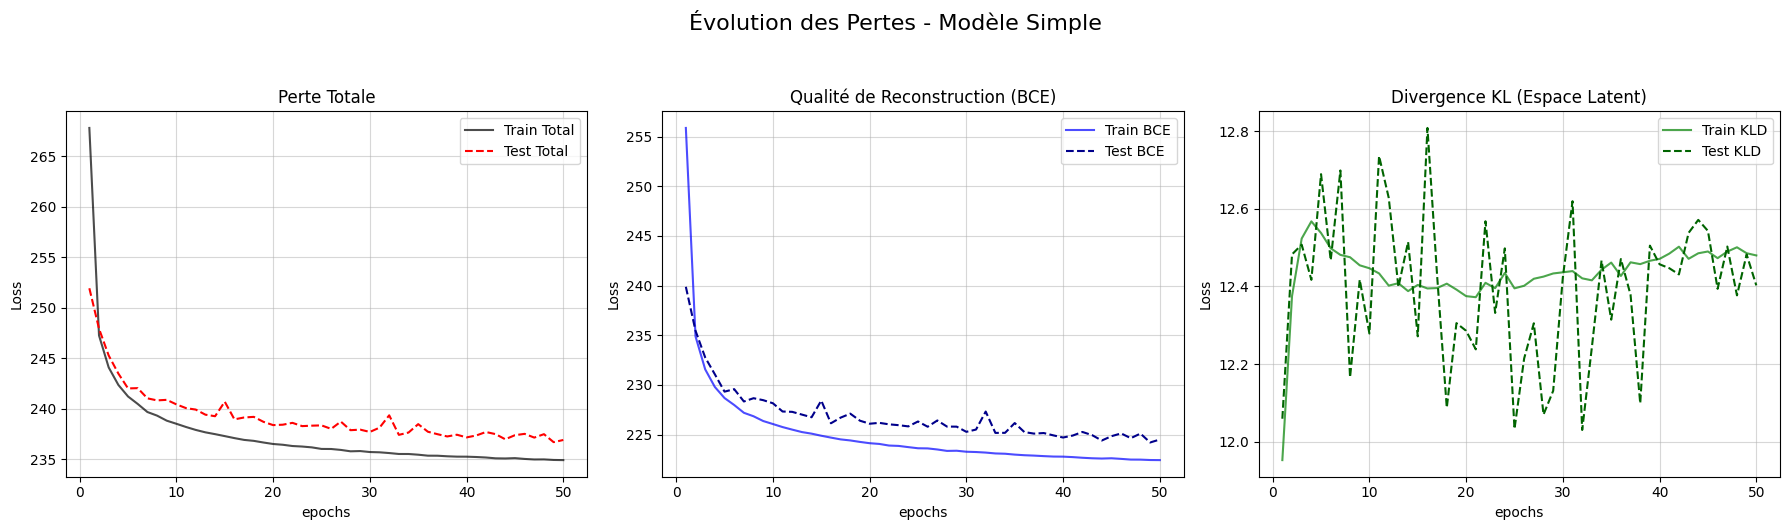

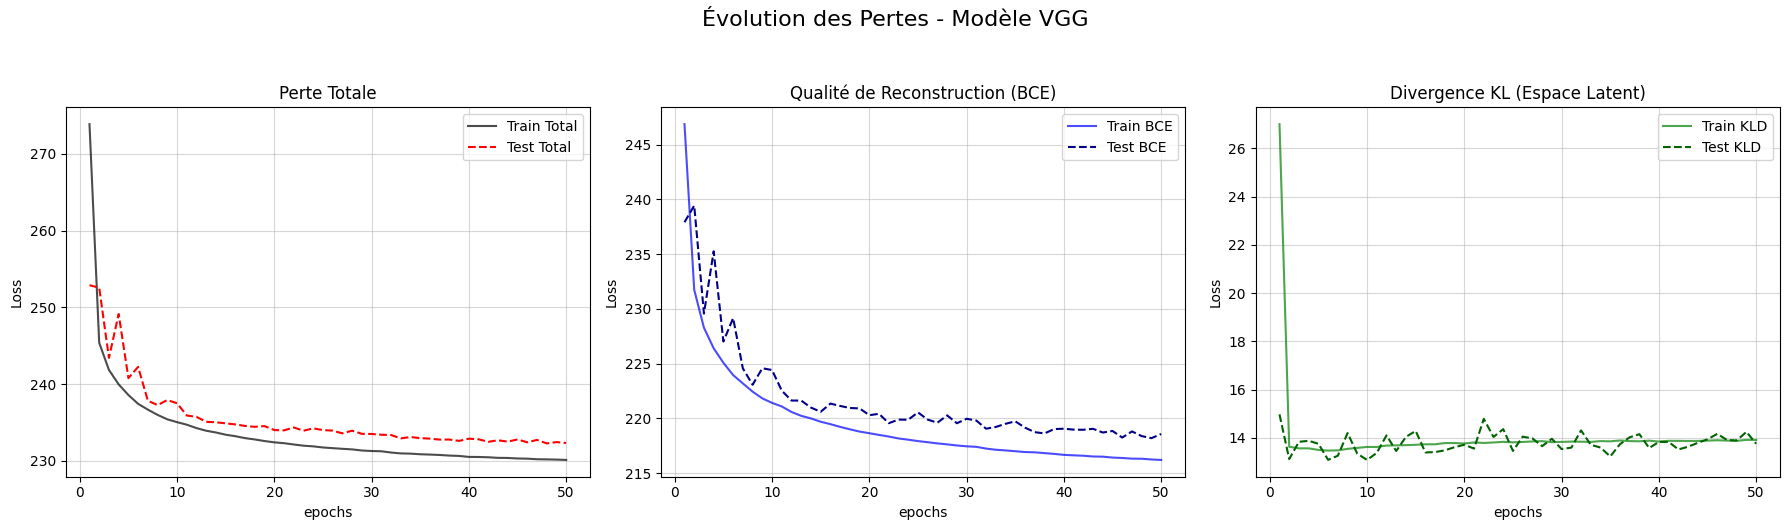

In [ ]:

plot_single_model_losses(history_simple, "Modèle Simple")
plot_single_model_losses(history_vgg, "Modèle VGG")

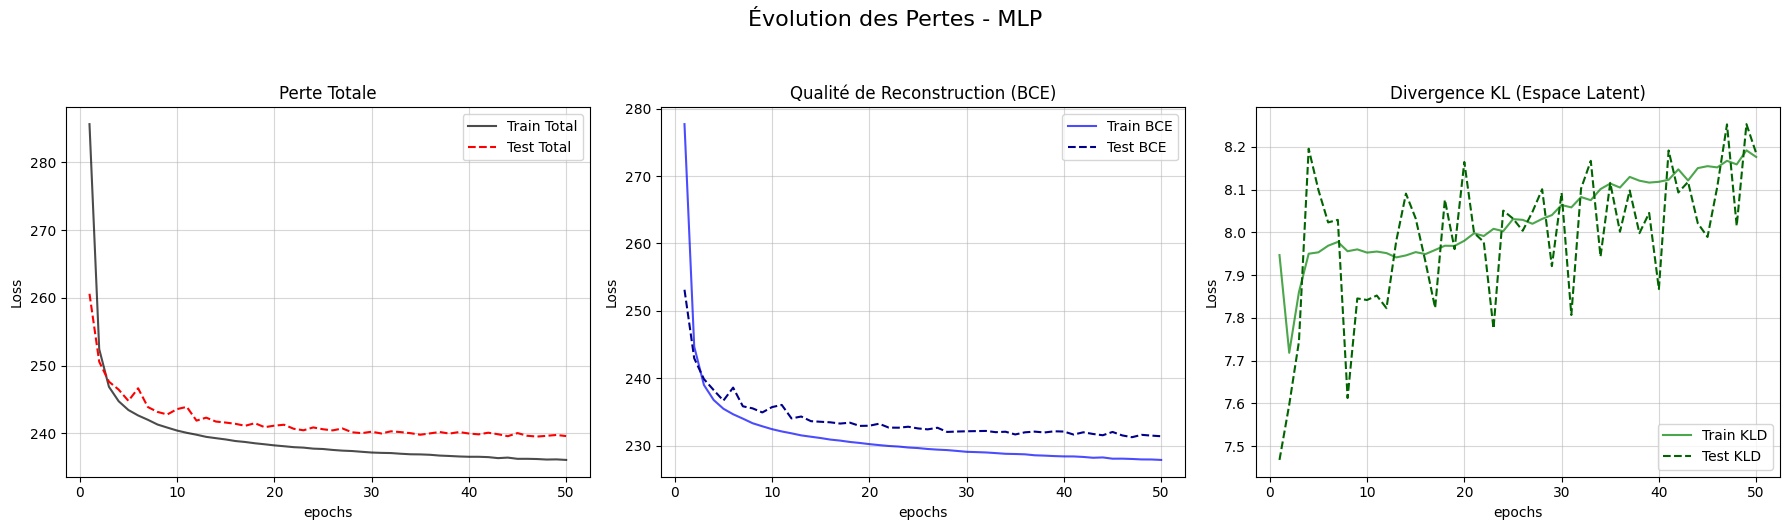

In [15]:
plot_single_model_losses(history_mlp, "MLP")

On these training loss graphs, we can see that KLD term is a regularization term : it's here to keep a certain form to the latent space. Meanwhile, BCE loss is here for the accuracy of the reconstruction : it's purpose is to have reconstructions close enough from the input. BCE and KLD are not that far (10^1 for KLD, 10^2 for BCE) so it's not mandatory to add a regularization weight. It could be done on purpose to give more weight to the latent space distribution.

We observe that conv and MLP architectures give relatively same training results but the overall loss is higher for MLP than conv architecture. In fact, KL divergence is smaller for MLP architecture which mean convolutionnal cvae are better to reconstruct the images but MLP cvae are better to project the input into a said latent space distribution.

To conclude about the choice of the architecture, it's clear that convolutionnal based CVAE are better than MLP based CVAE (if we consider the loss value). We will check that they also perform better for image generation.

In [63]:
torch.save(model_simple.state_dict(), "CVAE_simple_50ep.pth")
torch.save(model_vgg.state_dict(), "CVAE_VGGlike_50ep.pth")
print("Save.")

Save.


In [17]:
torch.save(model_mlp.state_dict(), "CVAE_MLP_50ep.pth" )
print("save.")

save.


## Results visualisation (generating items of different classes and latent space visualisation)

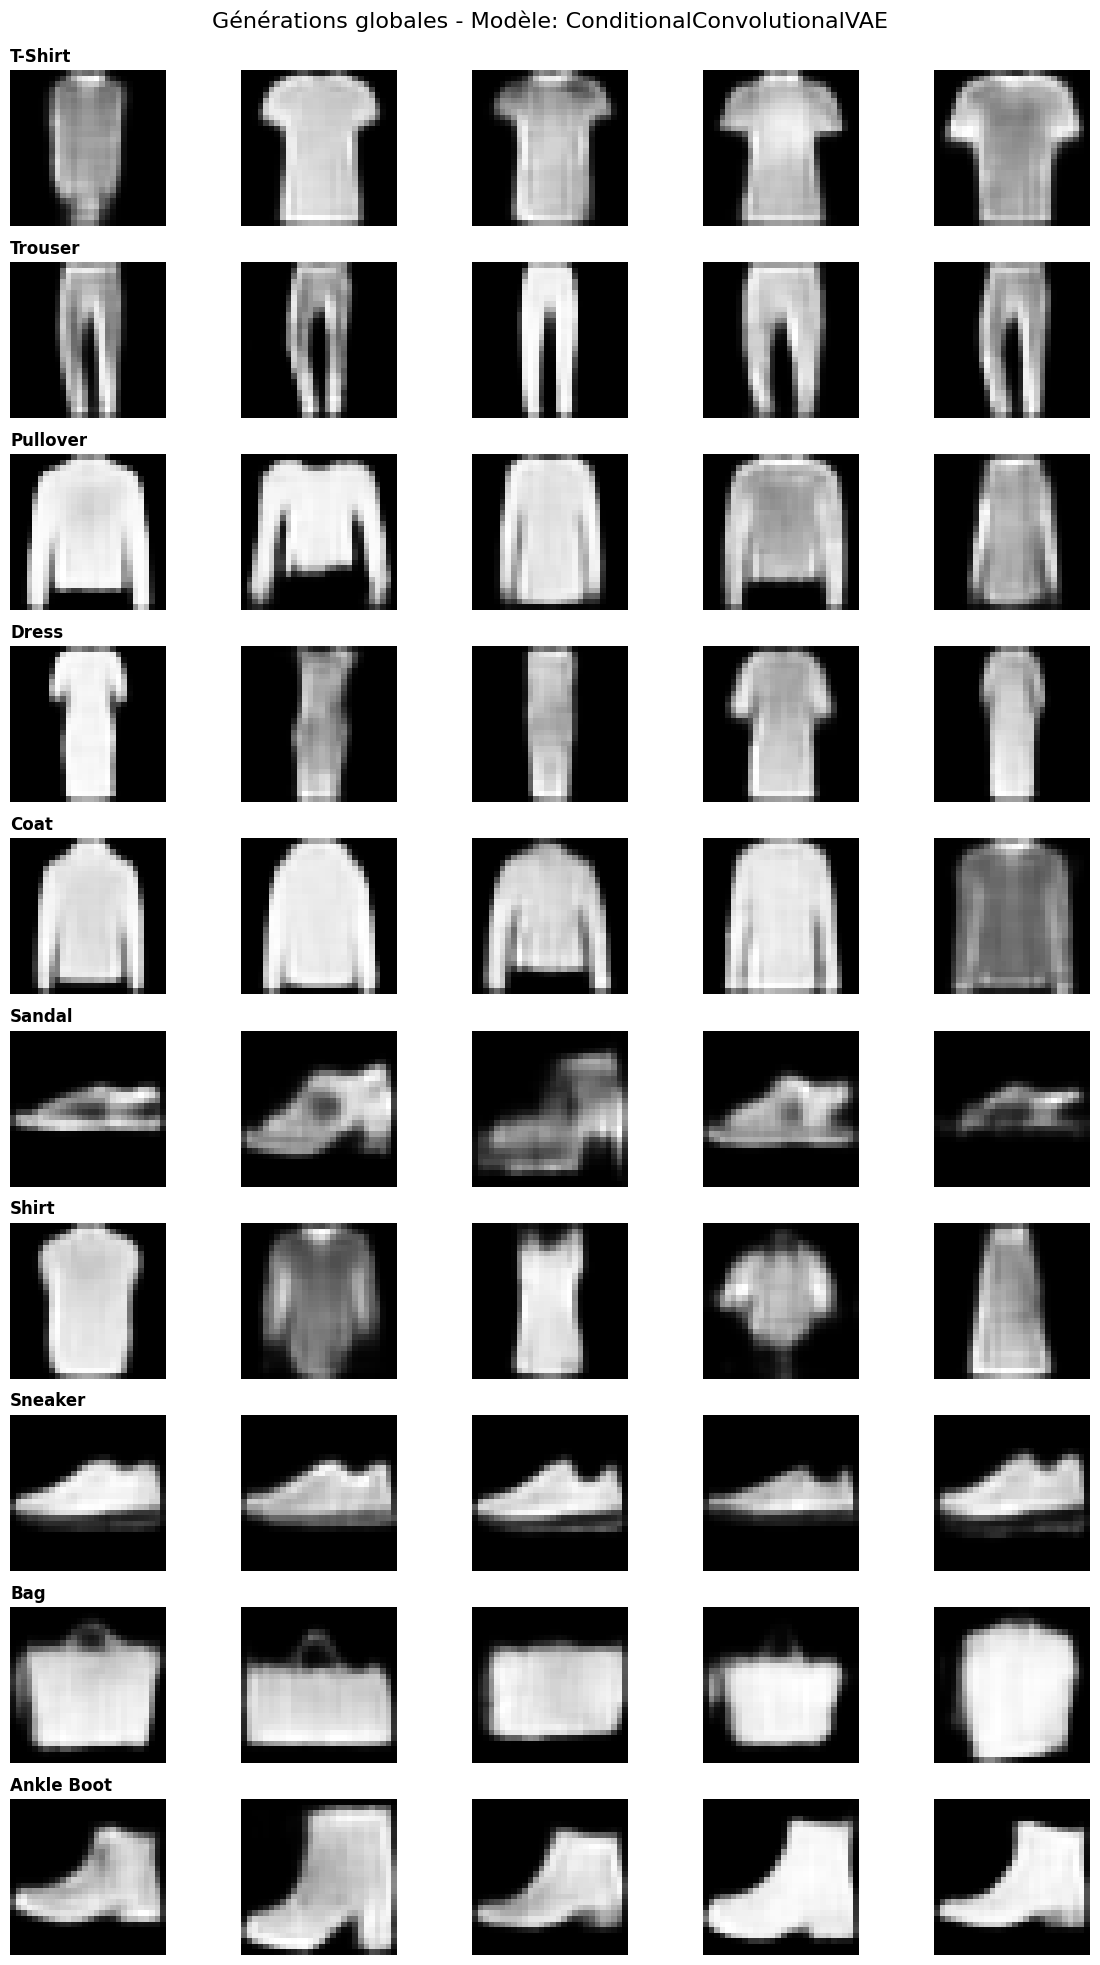

In [64]:
generate_all_classes(model_simple)

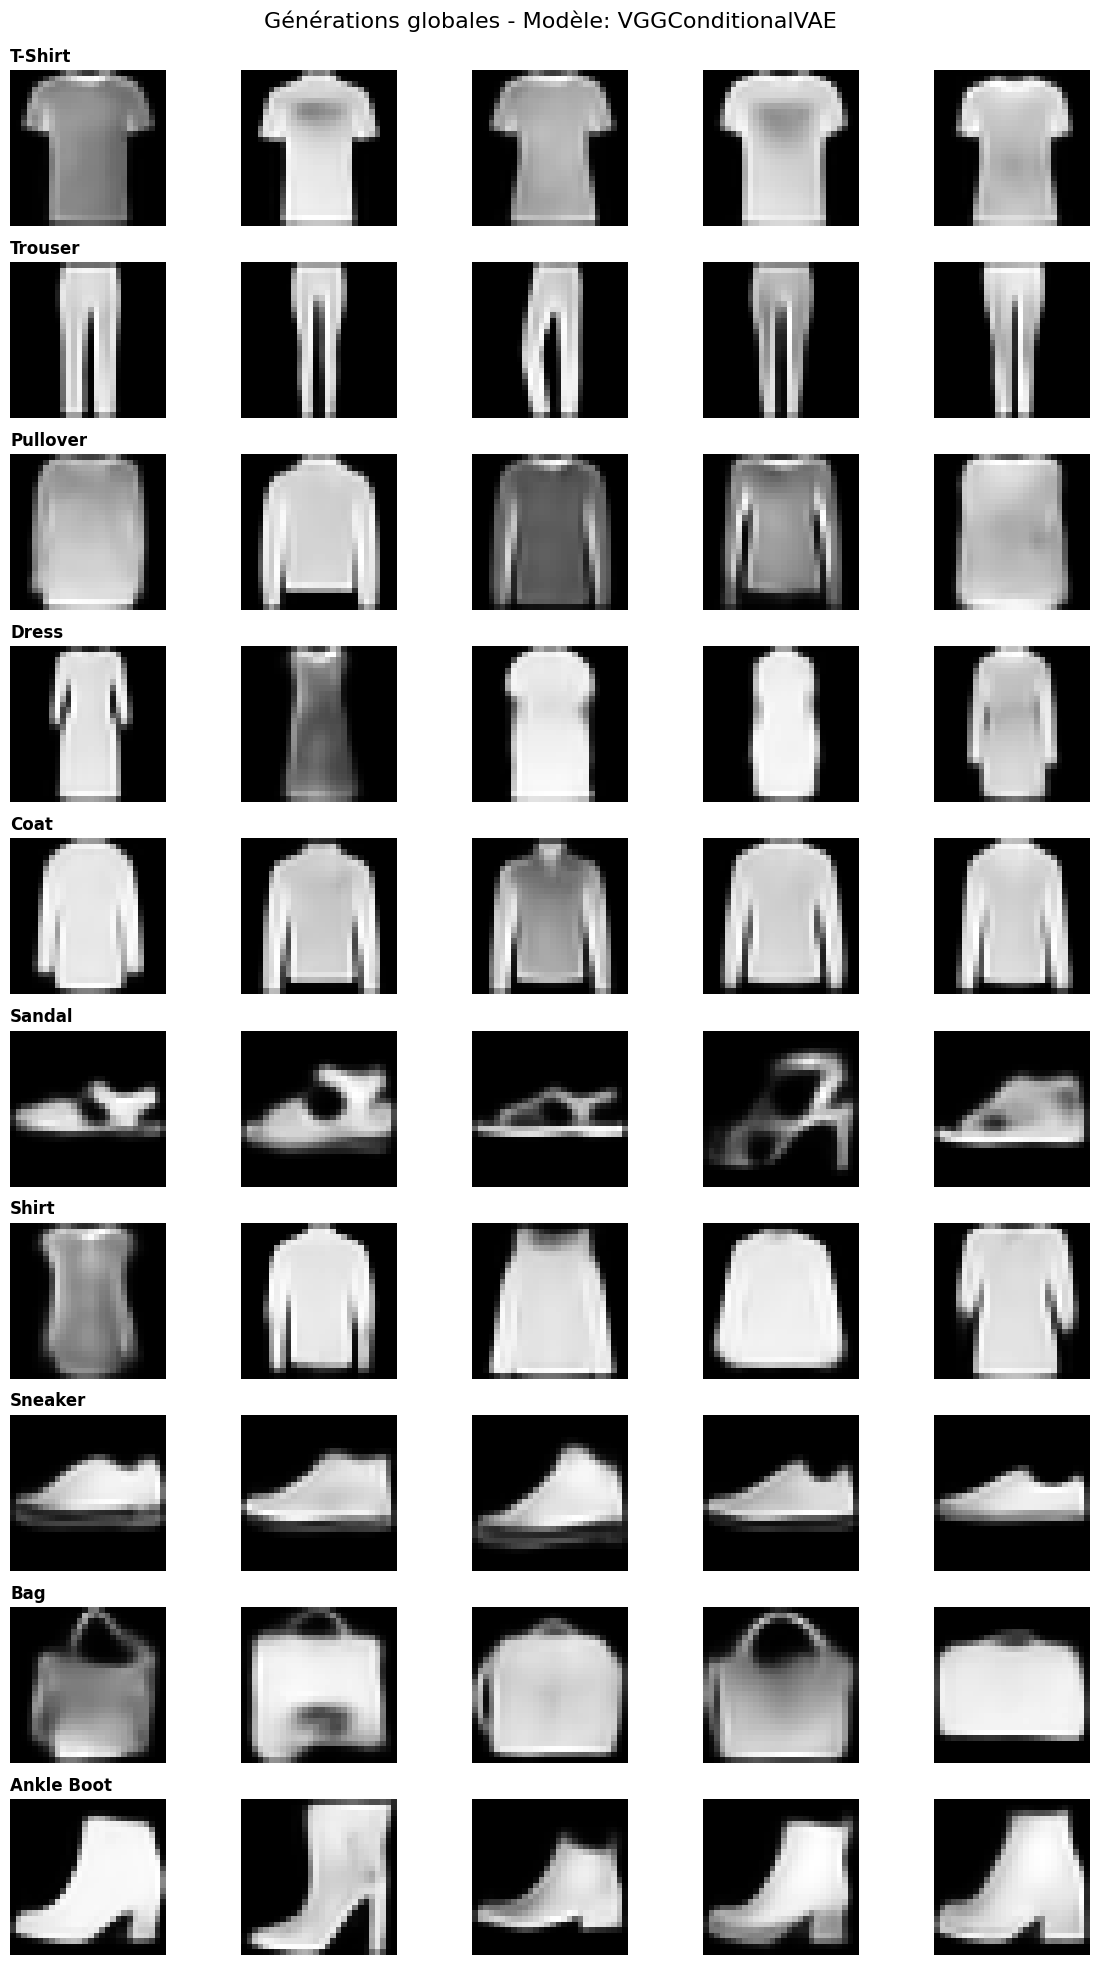

In [65]:
generate_all_classes(model_vgg)

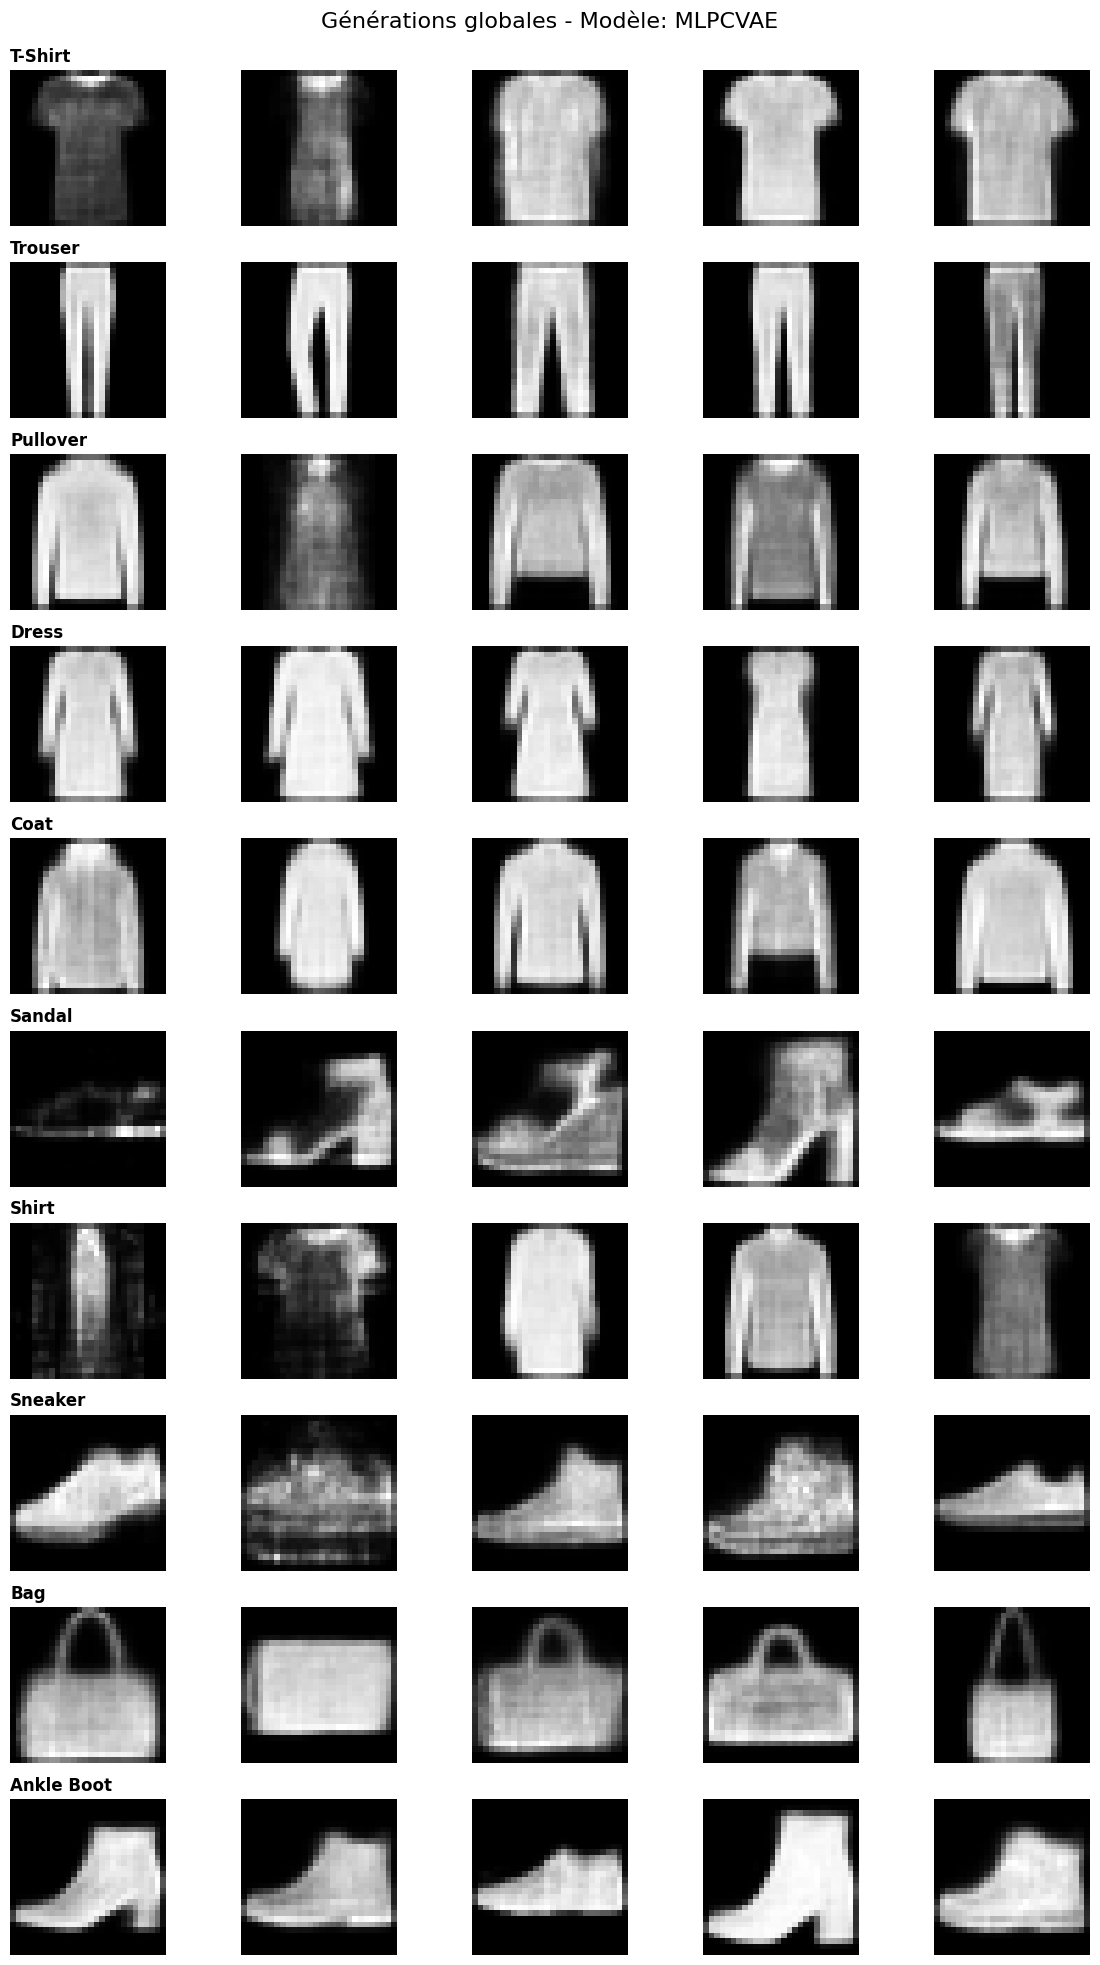

In [ ]:
LATENT_DIM = 64
generate_all_classes(model_mlp)
LATENT_DIM = 32

Generated samples for each class seems relatively accurate. It doesn't seem that one model outperforms the other, so we can guess that for this type of input, the simple model is enough. Reconstructions are accurate from a shape perspective but the edges seems very noisy. Of course, the fact that images are 28*28 plays a huge role in that noisy effect : event the input images are a bit blur. Overall, it seems that the model perform well at generating two classes that are totally different. For instance, if the user want to generate a shoe (ankle boot, sneaker or sandal) the usr will get a shoe as output. But generating a particular shoe does not work so well (some ankle boot generations looks like some sneaker or some sandal generations).

Considering the best architecture, it's relatively hard to say that one model is better at generating than another. Even for the mlp-based CVAE, reconstructions are kind of similar to the reconstructions of convolutionnal CVAE.

In [ ]:
from sklearn.manifold import TSNE

def plot_latent_space(model, num_batches=5):
    model.eval()
    latents = []
    labels_list = []
    
    with torch.no_grad():
        for i, (data, labels) in enumerate(test_loader):
            if i >= num_batches: break 
            
            data = data.to(DEVICE)
            labels_onehot = torch.nn.functional.one_hot(labels, num_classes=NUM_CLASSES).float().to(DEVICE)
            
            _, mu, _ = model(data, labels_onehot)
            
            latents.append(mu.cpu())
            labels_list.append(labels)

    latents = torch.cat(latents, dim=0).numpy()
    labels_list = torch.cat(labels_list, dim=0).numpy()

    tsne = TSNE(n_components=2)
    latents_2d = tsne.fit_transform(latents)

   
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels_list, cmap='tab10', alpha=0.7)
    
    labels_map = {0: "T-Shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat", 
                  5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"}
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.ax.set_yticklabels([labels_map[i] for i in range(10)])
    
    plt.title('Visualisation de l\'espace latent (t-SNE)')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.show()
    plt.close()

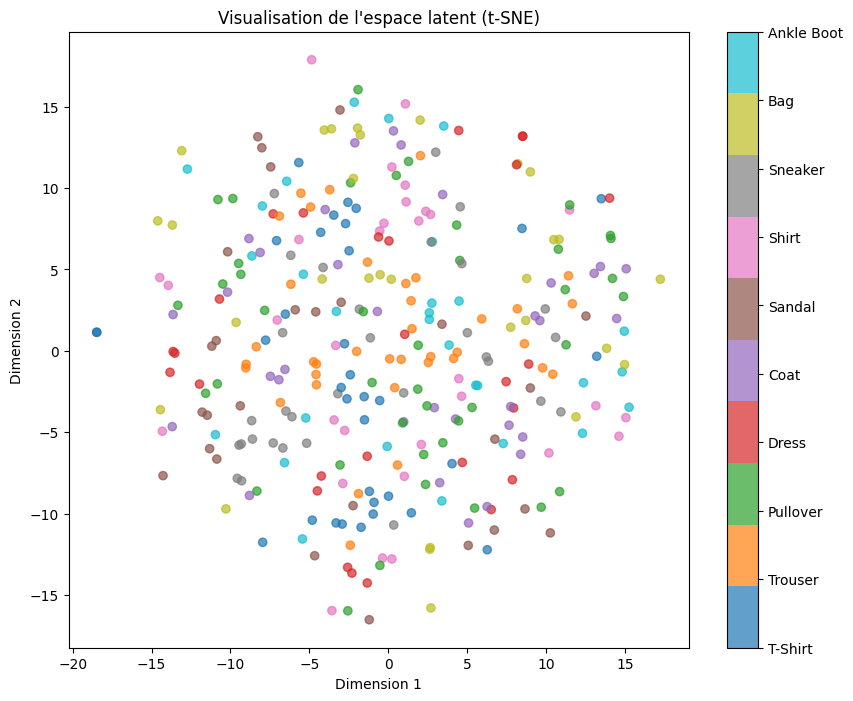

In [68]:
plot_latent_space(model_simple)

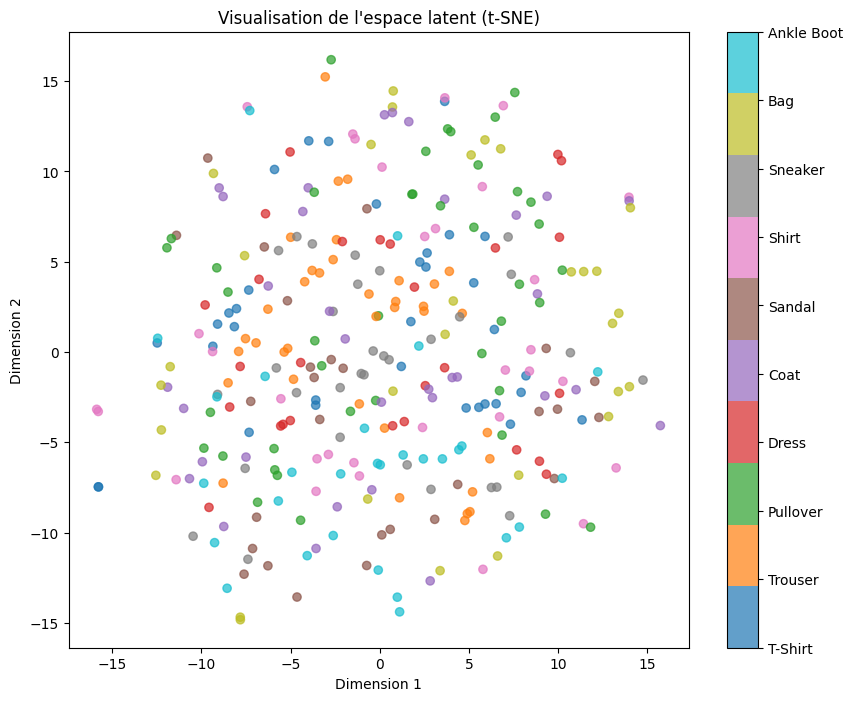

In [67]:
plot_latent_space(model_vgg)

Here are the latent space representation. We used a t-SNE algorithm to reduce our latent space into a 2 dimensional space in order to plot it. As expected, we obtain distributions that look the same for all of the classes. We do not see any impact of the architecture on the latent space.

## Conclusion

The project was to study conditionnal VAE and train them on the MNIST Fashion dataset in order to generate new items for each class of the dataset. To deal with it, we first studied the conditionnal vae algorithm. We used different papers and articles to help us understand and create three diferents CVAE architectures. We designed two convolutional CVAE (a simple one and a more complex one) and a CVAE with MLP as encoder and decoder.

We fixed the training hyperparameters using the articles and already done code on the MNIST fashion dataset.

We obtained the following results : conv CVAE are better on the reconstruction but MLP CVAE are better considering the KL regularization. Considering the overall loss, convolutionnal CVAE are a bit better than MLP. The complex conv CVAE is also a bit better than the simple conv CVAE.

For the item generation, it's hard to really tell if we obtain better results on one or another architecture. This might be due to the small size of the images (28*28*1).